# Company Data Preprocessing for Customer Segmentation

This notebook combines all company data sources and applies best-practice preprocessing for ML clustering.

**Data Sources:**
- Internal features: RFM metrics, product mix, operations complexity
- Companies House: Basic profile, officers, filings, charges
- Web presence: Website detection results

**Strategy:** Median imputation with missing indicators (recommended for clustering with MAR data)

In [68]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import tabulate

# Sklearn imports
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import FunctionTransformer, RobustScaler


import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))
from scripts.preprocessing_custom import FrequencyEncoder, TargetEncoder

## 1. Load All Data Sources

In [33]:
# Paths
DATA_DIR = Path('../data/companies')

# Load all datasets
df_main = pd.read_csv(DATA_DIR / 'company_features.csv')
df_internal = pd.read_csv(DATA_DIR / 'customer_stats.csv')
df_external = pd.read_csv(DATA_DIR / 'external_features.csv')
df_deep = pd.read_csv(DATA_DIR / 'deep_features.csv')
df_web = pd.read_csv(DATA_DIR / 'web_features.csv')

print("Dataset shapes:")
print(f"  Main (merged):     {df_main.shape}")
print(f"  Internal features: {df_internal.shape}")
print(f"  External (CH):     {df_external.shape}")
print(f"  Deep (CH):         {df_deep.shape}")
print(f"  Web presence:      {df_web.shape}")

Dataset shapes:
  Main (merged):     (908, 98)
  Internal features: (960, 13)
  External (CH):     (908, 11)
  Deep (CH):         (908, 11)
  Web presence:      (908, 6)


In [34]:
df_main["median_margin"].isna().sum()

62

In [35]:
# Use the main merged dataset
df = df_main.copy()
print(f"Working with {len(df)} companies and {len(df.columns)} features")
print(f"\nColumn list:")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2d}. {col}")

Working with 908 companies and 98 features

Column list:
   1. company
   2. recency_days
   3. first_order_days_ago
   4. tenure_days
   5. frequency
   6. monetary_total
   7. monetary_mean
   8. monetary_median
   9. monetary_std
  10. monetary_max
  11. monetary_min
  12. avg_days_between_orders
  13. std_days_between_orders
  14. min_days_between_orders
  15. max_days_between_orders
  16. orders_per_year
  17. avg_quantity
  18. median_quantity
  19. max_quantity
  20. min_quantity
  21. std_quantity
  22. avg_unit_price
  23. median_unit_price
  24. max_unit_price
  25. avg_margin
  26. median_margin
  27. ptype_binder_pct
  28. ptype_box_pct
  29. ptype_slip_case_pct
  30. ptype_folder_pct
  31. ptype_presentation_pack_pct
  32. ptype_menu_cover_pct
  33. ptype_ring_binder_pct
  34. ptype_lever_arch_pct
  35. ptype_portfolio_pct
  36. product_type_diversity
  37. has_product_type_pct
  38. avg_num_operations
  39. max_num_operations
  40. op_cutting_pct
  41. op_creasing_pct
  4

In [36]:
df.groupby('company').head(20)

,company,recency_days,first_order_days_ago,tenure_days,frequency,monetary_total,monetary_mean,monetary_median,monetary_std,monetary_max,monetary_min,avg_days_between_orders,std_days_between_orders,min_days_between_orders,max_days_between_orders,orders_per_year,avg_quantity,median_quantity,max_quantity,min_quantity,std_quantity,avg_unit_price,median_unit_price,max_unit_price,avg_margin,...,incorporation_date,company_age_years,region,accounts_type,officer_count,active_officer_count,director_count,secretary_count,filing_count,recent_filing_days,annual_accounts_count,has_charges,charge_count,psc_count,has_website,website_domain,has_https,http_status,domain_variant,orders_per_company_year,value_quintile,frequency_tier,is_active_12m,is_active_6m,is_churned
0,2D 25M,732.0,732.0,0,1,488.937778,488.937778,488.937778,0.000000,488.937778,488.937778,NaN,NaN,NaN,NaN,1.000000,100.000000,100.0,100.0,100.0,0.000000,4.889378,4.889378,4.889378,NaN,...,2025-10-23,0.3,Ilford,NaN,1.0,1.0,1.0,0.0,1.0,103.0,0.0,False,0.0,1.0,False,NaN,False,NaN,NaN,3.333333,1,one_time,False,False,True
1,4 CREATIVE,332.0,332.0,0,2,4206.560278,2103.280139,2103.280139,511.172795,2464.733889,1741.826389,0.000000,NaN,0.0,0.0,2.000000,150.000000,150.0,200.0,100.0,70.710678,16.358063,16.358063,19.160090,10.000000,...,2016-04-13,9.8,Ayr,NaN,5.0,1.0,1.0,0.0,15.0,2624.0,1.0,False,0.0,1.0,True,4creative.co.uk,True,200.0,co.uk,0.204082,4,occasional,True,False,False
2,4-PRINT,122.0,1359.0,1237,50,92947.490586,1858.949812,1123.726161,2048.564070,8863.439632,171.932500,25.244898,36.379098,0.0,147.0,14.763541,1277.960000,350.0,8500.0,5.0,2218.382965,10.381129,4.052838,58.791861,21.229592,...,1980-08-11,45.5,Surrey,total-exemption-full,7.0,2.0,1.0,1.0,106.0,320.0,38.0,True,2.0,1.0,True,4print.co.uk,False,200.0,co.uk,1.098901,5,power_user,True,True,False
3,A&M ELLIS,835.0,835.0,0,1,2640.344000,2640.344000,2640.344000,0.000000,2640.344000,2640.344000,NaN,NaN,NaN,NaN,1.000000,6000.000000,6000.0,6000.0,6000.0,0.000000,NaN,NaN,NaN,30.000000,...,2024-10-18,1.3,Newport,NaN,4.0,4.0,3.0,1.0,2.0,52.0,0.0,False,0.0,3.0,False,NaN,False,NaN,NaN,0.769231,3,one_time,False,False,True
4,ABC,430.0,1001.0,571,7,65388.244203,9341.177743,8809.312000,6200.955848,21661.695473,3135.783333,95.166667,114.436737,0.0,285.0,4.477671,4314.285714,1000.0,16250.0,200.0,6067.310929,6.415829,6.415829,6.415829,15.000000,...,2021-05-12,4.7,Cambridge,dormant,1.0,1.0,1.0,0.0,11.0,23.0,4.0,False,0.0,1.0,True,abc.co.uk,False,200.0,co.uk,1.489362,5,regular,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,WT & VC,448.0,448.0,0,1,876.466667,876.466667,876.466667,0.000000,876.466667,876.466667,NaN,NaN,NaN,NaN,1.000000,100.000000,100.0,100.0,100.0,0.000000,NaN,NaN,NaN,20.000000,...,2019-12-24,6.1,London,NaN,1.0,1.0,1.0,0.0,3.0,1679.0,0.0,False,0.0,1.0,False,NaN,False,NaN,NaN,0.163934,2,one_time,False,False,False
904,XIC,864.0,1843.0,979,3,2420.585417,806.861806,437.646667,908.151310,1841.468750,141.470000,489.500000,58.689863,448.0,531.0,1.119254,232.333333,50.0,635.0,12.0,349.236787,9.376820,10.503520,14.147000,20.000000,...,2016-03-29,9.8,London,NaN,2.0,2.0,2.0,0.0,11.0,2414.0,2.0,False,0.0,1.0,True,xic.com,True,301.0,com,0.306122,3,occasional,False,False,True
905,XPRESS GROUP,1680.0,1680.0,0,1,868.368000,868.368000,868.368000,0.000000,868.368000,868.368000,NaN,NaN,NaN,NaN,1.000000,504.000000,504.0,504.0,504.0,0.000000,1.722952,1.722952,1.722952,NaN,...,2023-12-16,2.1,London,micro-entity,1.0,1.0,1.0,0.0,4.0,35.0,1.0,False,0.0,1.0,True,xpress.co.uk,False,403.0,co.uk,0.476190,2,one_time,False,False,True
906,ZENITH,718.0,718.0,0,1,8637.854353,8637.854353,8637.854353,0.000000,8637.854353,8637.854353,NaN,NaN,NaN,NaN,1.000000,6000.000000,6000.0,6000.0,6000.0,0.000000,NaN,NaN,NaN,10.000000,...,2015-07-02,10.6,Glasgow,NaN,0.0,0.0,0.0,0.0,3.0,3122.0,0.0,Fal

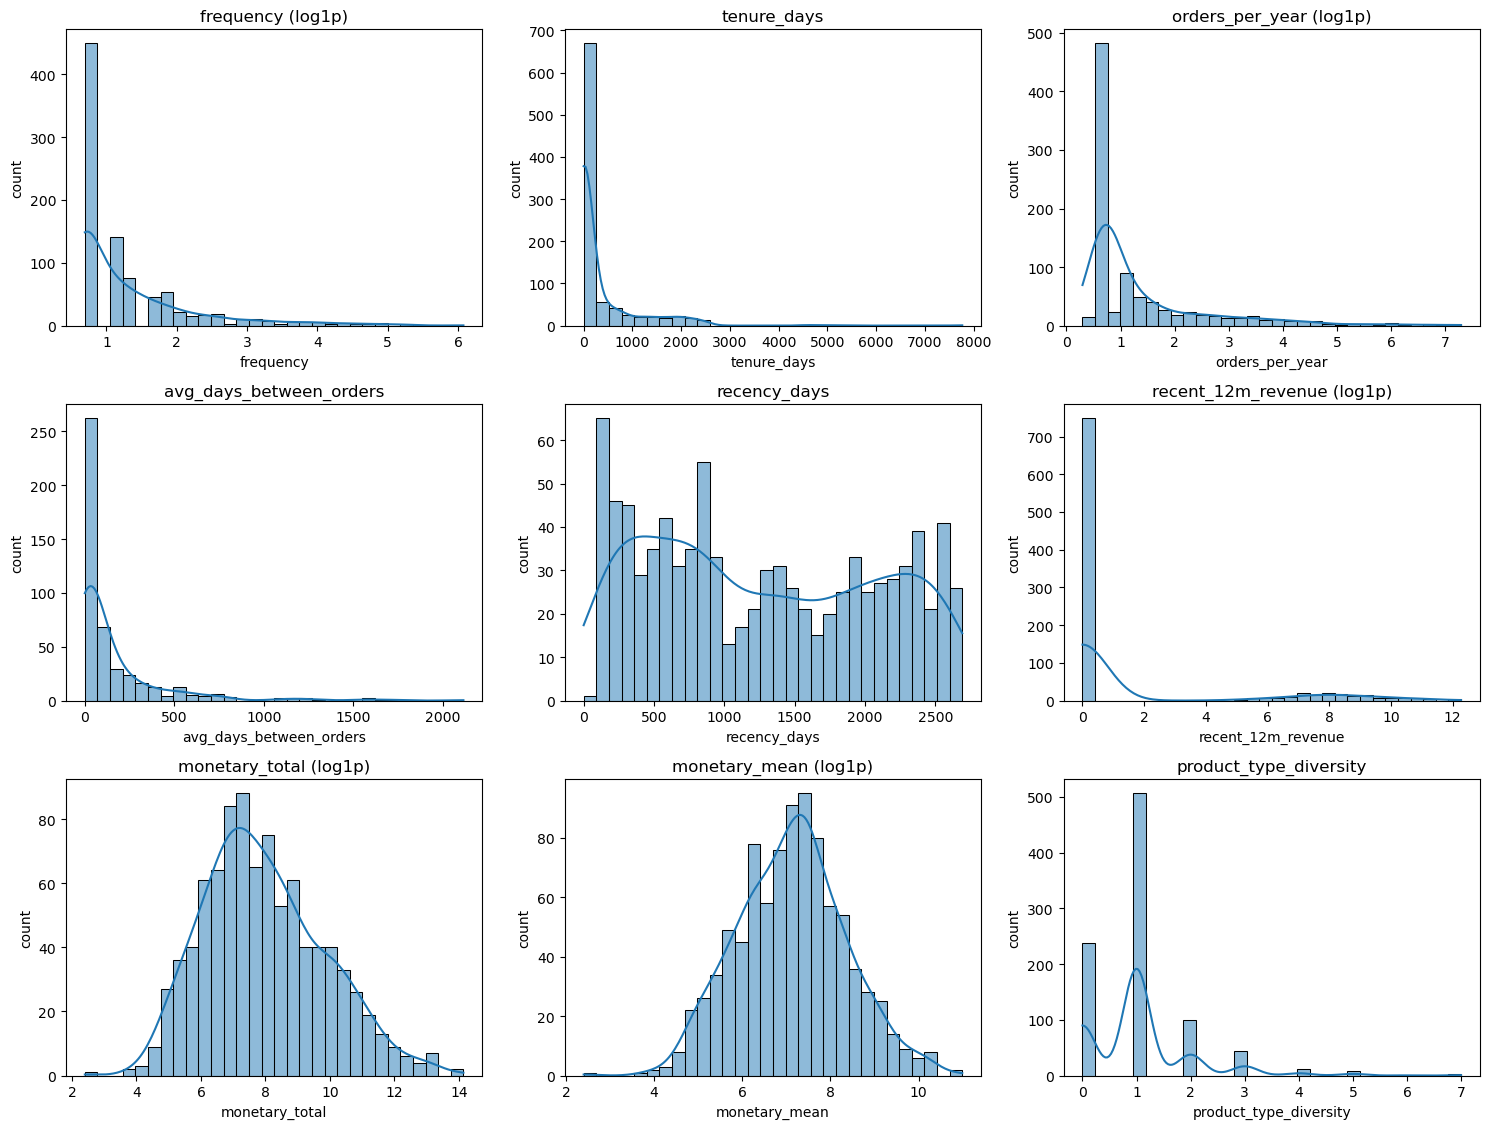

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

profile_cols = [
    "frequency",
    "tenure_days",
    "orders_per_year",
    "avg_days_between_orders",
    "recency_days",
    "recent_12m_revenue",
    "monetary_total",
    "monetary_mean",
    "product_type_diversity",
]

# Heuristic: these are usually heavy-tailed
log_cols = {"frequency", "orders_per_year", "monetary_total", "monetary_mean", "recent_12m_revenue"}

n_cols = 3
n_rows = int(np.ceil(len(profile_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.8*n_rows))
axes = axes.flatten()

for ax, col in zip(axes, profile_cols):
    x = df[col].dropna()

    # If log col, plot log1p(x) to make shape readable
    if col in log_cols:
        x_plot = np.log1p(x)
        sns.histplot(x_plot, kde=True, bins=30, ax=ax)
        ax.set_title(f"{col} (log1p)")
        ax.set_xlabel(col)
    else:
        sns.histplot(x, kde=True, bins=30, ax=ax)
        ax.set_title(col)
        ax.set_xlabel(col)

    ax.set_ylabel("count")

for ax in axes[len(profile_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

## 2. Missing Data Analysis

Understanding why data is missing is crucial:
- **MCAR** (Missing Completely at Random): Safe to drop or impute simply
- **MAR** (Missing at Random): Missingness depends on observed variables (e.g., no CH data because company not matched)
- **MNAR** (Missing Not at Random): Missingness depends on the missing value itself

In [38]:
def analyze_missing_data(df):
    """Comprehensive missing data analysis"""
    
    missing_summary = pd.DataFrame({
        'missing_count': df.isnull().sum(),
        'missing_pct': (df.isnull().sum() / len(df) * 100).round(2),
        'dtype': df.dtypes
    }).sort_values('missing_pct', ascending=False)
    
    print("=" * 70)
    print("MISSING DATA SUMMARY")
    print("=" * 70)
    print(f"Total companies:           {len(df)}")
    print(f"Total features:            {len(df.columns)}")
    print(f"Columns with any missing:  {(missing_summary['missing_pct'] > 0).sum()}")
    print(f"Columns with >50% missing: {(missing_summary['missing_pct'] > 50).sum()}")
    print(f"Columns with >70% missing: {(missing_summary['missing_pct'] > 70).sum()}")
    
    return missing_summary

missing_summary = analyze_missing_data(df)
print("\nTop 30 columns by missingness:")
display(missing_summary.head(30))

MISSING DATA SUMMARY
Total companies:           908
Total features:            98
Columns with any missing:  42
Columns with >50% missing: 4
Columns with >70% missing: 0

Top 30 columns by missingness:


,missing_count,missing_pct,dtype
std_days_between_orders,592,65.20,float64
max_unit_price,472,51.98,float64
median_unit_price,472,51.98,float64
avg_unit_price,472,51.98,float64
avg_days_between_orders,449,49.45,float64
min_days_between_orders,449,49.45,float64
max_days_between_orders,449,49.45,float64
http_status,209,23.02,float64
website_domain,209,23.02,object
domain_variant,209,23.02,object


In [39]:
cols = ["avg_days_between_orders", "min_days_between_orders", "max_days_between_orders"]
mask = df["tenure_days"].eq(0)

df.loc[mask, cols] = df.loc[mask, cols].fillna(0)

In [40]:
drop_cols = ['std_days_between_orders', 'max_unit_price', 'median_unit_price', 'avg_unit_price', 'incorporation_date', 'sic_codes', 'accounts_type']
df = df.drop(columns = drop_cols)

In [41]:
missing_summary = analyze_missing_data(df)
print("\nTop 30 columns by missingness:")
display(missing_summary.head(100))

MISSING DATA SUMMARY
Total companies:           908
Total features:            91
Columns with any missing:  32
Columns with >50% missing: 0
Columns with >70% missing: 0

Top 30 columns by missingness:


,missing_count,missing_pct,dtype
website_domain,209,23.02,object
http_status,209,23.02,float64
domain_variant,209,23.02,object
median_margin,62,6.83,float64
avg_margin,62,6.83,float64
industry_sector,53,5.84,object
region,30,3.30,object
company_age_years,19,2.09,float64
recent_filing_days,19,2.09,float64
company_status,16,1.76,object


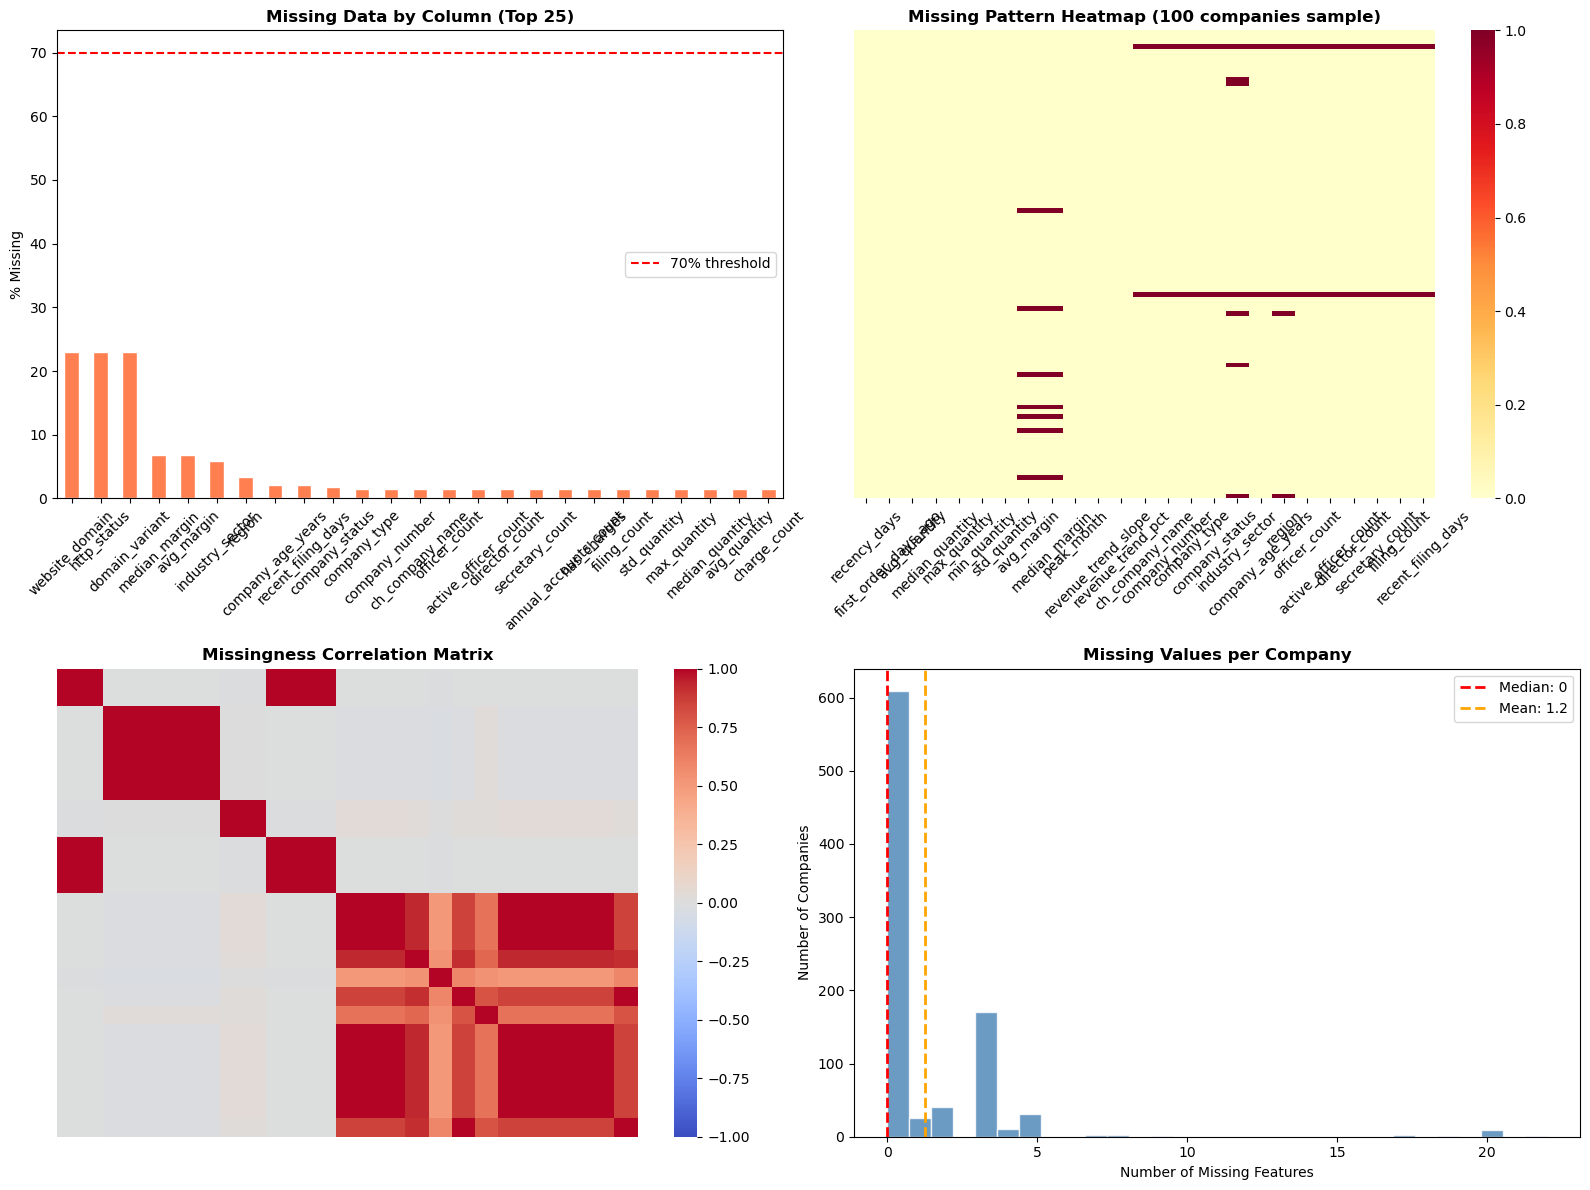

In [42]:
def plot_missing_patterns(df):
    """Visualize missing data patterns"""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Bar chart of missing percentages
    missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    missing_pct = missing_pct[missing_pct > 0]
    
    ax1 = axes[0, 0]
    if len(missing_pct) > 0:
        missing_pct.head(25).plot(kind='bar', ax=ax1, color='coral', edgecolor='white')
        ax1.set_title('Missing Data by Column (Top 25)', fontsize=12, fontweight='bold')
        ax1.set_ylabel('% Missing')
        ax1.tick_params(axis='x', rotation=45)
        ax1.axhline(y=70, color='red', linestyle='--', label='70% threshold')
        ax1.legend()
    else:
        ax1.text(0.5, 0.5, 'No missing data!', ha='center', va='center', fontsize=14)
    
    # 2. Missing data heatmap (sample of columns)
    ax2 = axes[0, 1]
    cols_with_missing = df.columns[df.isnull().any()].tolist()[:25]
    if cols_with_missing:
        sample_df = df[cols_with_missing].sample(min(100, len(df)), random_state=42)
        sns.heatmap(sample_df.isnull(), cbar=True, ax=ax2, cmap='YlOrRd',
                    xticklabels=True, yticklabels=False)
        ax2.set_title('Missing Pattern Heatmap (100 companies sample)', fontsize=12, fontweight='bold')
        ax2.tick_params(axis='x', rotation=45)
    
    # 3. Correlation of missingness
    ax3 = axes[1, 0]
    if len(cols_with_missing) > 1:
        missing_corr = df[cols_with_missing].isnull().corr()
        sns.heatmap(missing_corr, cmap='coolwarm', center=0, ax=ax3,
                    xticklabels=False, yticklabels=False, vmin=-1, vmax=1)
        ax3.set_title('Missingness Correlation Matrix', fontsize=12, fontweight='bold')
    
    # 4. Distribution of missing values per row
    ax4 = axes[1, 1]
    missing_per_row = df.isnull().sum(axis=1)
    ax4.hist(missing_per_row, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax4.axvline(missing_per_row.median(), color='red', linestyle='--', linewidth=2,
                label=f'Median: {missing_per_row.median():.0f}')
    ax4.axvline(missing_per_row.mean(), color='orange', linestyle='--', linewidth=2,
                label=f'Mean: {missing_per_row.mean():.1f}')
    ax4.set_title('Missing Values per Company', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Number of Missing Features')
    ax4.set_ylabel('Number of Companies')
    ax4.legend()
    
    plt.tight_layout()
    plt.savefig('../outputs/missing_data_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return missing_pct

missing_pct = plot_missing_patterns(df)

In [43]:
# Identify missing data patterns
def identify_missing_patterns(df):
    """Identify groups of columns that are missing together"""
    
    cols_with_missing = df.columns[df.isnull().any()].tolist()
    if not cols_with_missing:
        print("No missing data found!")
        return None
    
    # Create missingness indicator matrix
    missing_matrix = df[cols_with_missing].isnull().astype(int)
    
    # Find unique missing patterns
    pattern_strings = missing_matrix.apply(lambda x: ''.join(x.astype(str)), axis=1)
    pattern_counts = pattern_strings.value_counts()
    
    print("=" * 70)
    print("MISSING DATA PATTERNS")
    print("=" * 70)
    print(f"Unique patterns: {len(pattern_counts)}")
    print(f"\nTop 10 patterns:")
    
    for i, (pattern, count) in enumerate(pattern_counts.head(10).items()):
        pct = count / len(df) * 100
        missing_cols = [col for col, val in zip(cols_with_missing, pattern) if val == '1']
        print(f"\nPattern {i+1}: {count} companies ({pct:.1f}%)")
        if missing_cols:
            print(f"  Missing: {missing_cols[:5]}{'...' if len(missing_cols) > 5 else ''}")
        else:
            print(f"  Complete rows (no missing in these columns)")
    
    return pattern_counts

patterns = identify_missing_patterns(df)

MISSING DATA PATTERNS
Unique patterns: 25

Top 10 patterns:

Pattern 1: 609 companies (67.1%)
  Complete rows (no missing in these columns)

Pattern 2: 168 companies (18.5%)
  Missing: ['website_domain', 'http_status', 'domain_variant']

Pattern 3: 39 companies (4.3%)
  Missing: ['avg_margin', 'median_margin']

Pattern 4: 21 companies (2.3%)
  Missing: ['industry_sector']

Pattern 5: 17 companies (1.9%)
  Missing: ['avg_margin', 'median_margin', 'website_domain', 'http_status', 'domain_variant']

Pattern 6: 11 companies (1.2%)
  Missing: ['avg_quantity', 'median_quantity', 'max_quantity', 'min_quantity', 'std_quantity']

Pattern 7: 9 companies (1.0%)
  Missing: ['ch_company_name', 'company_number', 'company_type', 'company_status', 'industry_sector']...

Pattern 8: 8 companies (0.9%)
  Missing: ['industry_sector', 'website_domain', 'http_status', 'domain_variant']

Pattern 9: 5 companies (0.6%)
  Missing: ['region']

Pattern 10: 3 companies (0.3%)
  Missing: ['ch_company_name', 'compan

## 3. Feature Classification

Classify features by type and source for targeted handling.

In [44]:
def classify_features(df):
    """Classify features by type and source"""
    
    feature_groups = {
        # Identifiers (exclude from ML)
        'identifiers': [],
        
        # Internal RFM features
        'internal_numerical': [],
        
        # Companies House numerical
        'ch_numerical': [],
        
        # Companies House categorical
        'ch_categorical': [],
        
        # Binary flags
        'binary': [],
        
        # Other
        'other': []
    }
    
    # Classification rules
    id_keywords = ['company', 'name', 'number', 'address', 'postcode', 'url']
    internal_keywords = ['recency', 'frequency', 'monetary', 'order', 'revenue', 
                         'product', 'complexity', 'rfm', 'ratio', 'tier', 'quintile',
                         'avg_', 'total_', 'unique_', 'first_', 'last_', 'days_']
    ch_num_keywords = ['age', 'officer', 'filing', 'overdue', 'charge', 'accounts',
                       'confirmation', 'psc', 'active_', 'resigned_']
    ch_cat_keywords = ['status', 'type', 'jurisdiction', 'sic', 'category']
    binary_keywords = ['has_', 'is_', 'matched', 'bool']
    
    for col in df.columns:
        col_lower = col.lower()
        dtype = df[col].dtype
        
        # Check identifiers first
        if any(kw in col_lower for kw in id_keywords) and dtype == 'object':
            feature_groups['identifiers'].append(col)
        elif any(kw in col_lower for kw in binary_keywords) or (dtype == 'float64' and df[col].dropna().isin([0, 1]).all()):
            feature_groups['binary'].append(col)
        elif any(kw in col_lower for kw in ch_cat_keywords) and dtype == 'object':
            feature_groups['ch_categorical'].append(col)
        elif any(kw in col_lower for kw in ch_num_keywords) and dtype in ['float64', 'int64']:
            feature_groups['ch_numerical'].append(col)
        elif any(kw in col_lower for kw in internal_keywords) and dtype in ['float64', 'int64']:
            feature_groups['internal_numerical'].append(col)
        elif dtype in ['float64', 'int64']:
            feature_groups['other'].append(col)
        elif dtype == 'object':
            feature_groups['ch_categorical'].append(col)
        else:
            feature_groups['other'].append(col)
    
    # Print summary
    print("=" * 70)
    print("FEATURE CLASSIFICATION")
    print("=" * 70)
    for group, cols in feature_groups.items():
        print(f"\n{group.upper()} ({len(cols)} features):")
        for col in cols[:10]:
            missing_pct = df[col].isnull().mean() * 100
            print(f"  - {col} ({missing_pct:.1f}% missing)")
        if len(cols) > 10:
            print(f"  ... and {len(cols) - 10} more")
    
    return feature_groups

feature_groups = classify_features(df)

FEATURE CLASSIFICATION

IDENTIFIERS (5 features):
  - company (0.0% missing)
  - ch_company_name (1.5% missing)
  - company_number (1.5% missing)
  - company_type (1.5% missing)
  - company_status (1.8% missing)

INTERNAL_NUMERICAL (26 features):
  - recency_days (0.1% missing)
  - first_order_days_ago (0.1% missing)
  - frequency (0.0% missing)
  - monetary_total (0.0% missing)
  - monetary_mean (0.0% missing)
  - monetary_median (0.0% missing)
  - monetary_std (0.0% missing)
  - monetary_max (0.0% missing)
  - monetary_min (0.0% missing)
  - avg_days_between_orders (0.0% missing)
  ... and 16 more

CH_NUMERICAL (8 features):
  - company_age_years (2.1% missing)
  - officer_count (1.5% missing)
  - active_officer_count (1.5% missing)
  - filing_count (1.5% missing)
  - recent_filing_days (2.1% missing)
  - annual_accounts_count (1.5% missing)
  - charge_count (1.5% missing)
  - psc_count (1.5% missing)

CH_CATEGORICAL (5 features):
  - industry_sector (5.8% missing)
  - region (3.3% m

## 4. Data Preprocessing Pipeline

**Strategy (recommended by data scientist):**
1. **Categorical**: Fill with 'Unknown' category
2. **Numerical**: Median imputation + missing indicator columns
3. **Binary**: Domain-informed fill (usually 0)
4. Drop columns with >70% missing
5. Drop rows with >50% missing features

In [45]:
class CustomerSegmentationPreprocessor:
    """Complete preprocessing pipeline for customer segmentation"""
    
    def __init__(self, df, feature_groups):
        self.df_original = df.copy()
        self.df = df.copy()
        self.feature_groups = feature_groups
        self.preprocessing_log = []
        self.missing_indicator_cols = []
        
    def _log(self, message):
        self.preprocessing_log.append(message)
        print(message)
    
    def create_ch_matched_indicator(self):
        """Create indicator for Companies House data availability"""
        
        if 'ch_matched' not in self.df.columns:
            ch_cols = self.feature_groups.get('ch_numerical', []) + \
                      self.feature_groups.get('ch_categorical', [])
            
            if ch_cols:
                self.df['ch_matched'] = (~self.df[ch_cols].isnull().all(axis=1)).astype(int)
                self.feature_groups['binary'].append('ch_matched')
                ch_matched_pct = self.df['ch_matched'].mean() * 100
                self._log(f"Created ch_matched indicator: {ch_matched_pct:.1f}% matched")
        
        return self
    
    def handle_categorical(self):
        """Handle categorical missing values with 'Unknown' category"""
        
        self._log("\n--- Handling Categorical Features ---")
        
        for col in self.feature_groups.get('ch_categorical', []):
            if col in self.df.columns:
                missing_pct = self.df[col].isnull().mean() * 100
                
                if missing_pct > 0:
                    if self.df[col].dtype == 'object':
                        self.df[col] = self.df[col].fillna('Unknown')
                    else:
                        self.df[col] = self.df[col].fillna(-999)
                    
                    self._log(f"  {col}: {missing_pct:.1f}% -> 'Unknown'")
        
        return self
    
    def handle_numerical(self):
        """Handle numerical missing with median + indicator columns"""
        
        self._log("\n--- Handling Numerical Features (Median + Indicator) ---")
        
        numerical_cols = self.feature_groups.get('internal_numerical', []) + \
                         self.feature_groups.get('ch_numerical', []) + \
                         self.feature_groups.get('other', [])
        
        for col in numerical_cols:
            if col in self.df.columns and col not in self.feature_groups.get('identifiers', []):
                missing_pct = self.df[col].isnull().mean() * 100
                
                if missing_pct > 0:
                    # Create missing indicator
                    indicator_col = f'{col}_missing'
                    self.df[indicator_col] = self.df[col].isnull().astype(int)
                    self.missing_indicator_cols.append(indicator_col)
                    
                    # Impute with median
                    median_val = self.df[col].median()
                    self.df[col] = self.df[col].fillna(median_val)
                    
                    self._log(f"  {col}: {missing_pct:.1f}% missing, median={median_val:.2f}")
        
        return self
    
    def handle_binary(self):
        """Handle binary missing values"""
        
        self._log("\n--- Handling Binary Features ---")
        
        # Domain-specific fill values
        fill_rules = {
            'has_website': 0,
            'has_charges': 0,
            'has_insolvency_history': 0,
            'is_community_interest_company': 0,
            'has_been_liquidated': 0,
            'ch_matched': 0
        }
        
        for col in self.feature_groups.get('binary', []):
            if col in self.df.columns:
                missing_pct = self.df[col].isnull().mean() * 100
                
                if missing_pct > 0:
                    fill_val = fill_rules.get(col, 0)
                    self.df[col] = self.df[col].fillna(fill_val)
                    self._log(f"  {col}: {missing_pct:.1f}% -> {fill_val}")
        
        return self
    
    def drop_high_missing_columns(self, threshold=70):
        """Drop columns with >threshold% missing"""
        
        self._log(f"\n--- Dropping Columns with >{threshold}% Missing ---")
        
        missing_pct = self.df.isnull().mean() * 100
        high_missing = missing_pct[missing_pct > threshold].index.tolist()
        
        # Don't drop identifiers even if missing
        high_missing = [c for c in high_missing if c not in self.feature_groups.get('identifiers', [])]
        
        if high_missing:
            self._log(f"  Dropping {len(high_missing)} columns:")
            for col in high_missing:
                self._log(f"    - {col} ({missing_pct[col]:.1f}% missing)")
            self.df = self.df.drop(columns=high_missing, errors='ignore')
        else:
            self._log("  No columns to drop")
        
        return self
    
    def drop_low_quality_rows(self, threshold=50):
        """Drop rows with >threshold% missing features"""
        
        self._log(f"\n--- Dropping Rows with >{threshold}% Missing ---")
        
        # Calculate % missing per row
        missing_per_row = self.df.isnull().sum(axis=1)
        total_cols = len(self.df.columns)
        missing_pct_per_row = missing_per_row / total_cols * 100
        
        rows_to_drop = self.df[missing_pct_per_row > threshold].index
        
        if len(rows_to_drop) > 0:
            self._log(f"  Dropping {len(rows_to_drop)} rows")
            self.df = self.df.drop(index=rows_to_drop, errors='ignore')
        else:
            self._log("  No rows to drop")
        
        return self
    
    def verify_no_missing(self):
        """Verify no missing data remains in feature columns"""
        
        self._log("\n--- Verification ---")
        
        # Check non-identifier columns
        feature_cols = [c for c in self.df.columns if c not in self.feature_groups.get('identifiers', [])]
        remaining_missing = self.df[feature_cols].isnull().sum().sum()
        
        if remaining_missing > 0:
            self._log(f"  WARNING: {remaining_missing} missing values remain")
            missing_cols = self.df[feature_cols].columns[self.df[feature_cols].isnull().any()]
            for col in missing_cols:
                self._log(f"    - {col}: {self.df[col].isnull().sum()} missing")
        else:
            self._log("  SUCCESS: No missing values in feature columns")
        
        return self
    
    def run_pipeline(self):
        """Run complete preprocessing pipeline"""
        
        self._log("=" * 70)
        self._log("PREPROCESSING PIPELINE")
        self._log("=" * 70)
        self._log(f"Starting with {len(self.df)} companies, {len(self.df.columns)} features")
        
        return (self
                .create_ch_matched_indicator()
                .handle_categorical()
                .handle_numerical()
                .handle_binary()
                .drop_high_missing_columns(threshold=70)
                .drop_low_quality_rows(threshold=50)
                .verify_no_missing())
    
    def get_data(self):
        """Get processed data"""
        return {
            'df': self.df,
            'original': self.df_original,
            'log': self.preprocessing_log,
            'missing_indicators': self.missing_indicator_cols
        }

In [46]:
# Run the preprocessing pipeline
preprocessor = CustomerSegmentationPreprocessor(df, feature_groups)
preprocessor.run_pipeline()

# Get processed data
result = preprocessor.get_data()
df_processed = result['df']

print(f"\n" + "=" * 70)
print("PIPELINE COMPLETE")
print("=" * 70)
print(f"Original:  {len(df)} companies, {len(df.columns)} features")
print(f"Processed: {len(df_processed)} companies, {len(df_processed.columns)} features")
print(f"Missing indicator columns added: {len(result['missing_indicators'])}")

PREPROCESSING PIPELINE
Starting with 908 companies, 91 features
Created ch_matched indicator: 100.0% matched

--- Handling Categorical Features ---
  industry_sector: 5.8% -> 'Unknown'
  region: 3.3% -> 'Unknown'
  website_domain: 23.0% -> 'Unknown'
  domain_variant: 23.0% -> 'Unknown'

--- Handling Numerical Features (Median + Indicator) ---
  recency_days: 0.1% missing, median=1184.00
  first_order_days_ago: 0.1% missing, median=1661.00
  avg_quantity: 1.5% missing, median=477.12
  avg_margin: 6.8% missing, median=20.00
  revenue_trend_slope: 0.1% missing, median=0.00
  revenue_trend_pct: 0.1% missing, median=0.00
  company_age_years: 2.1% missing, median=13.70
  officer_count: 1.5% missing, median=3.00
  active_officer_count: 1.5% missing, median=2.00
  filing_count: 1.5% missing, median=34.50
  recent_filing_days: 2.1% missing, median=128.00
  annual_accounts_count: 1.5% missing, median=10.00
  charge_count: 1.5% missing, median=0.00
  psc_count: 1.5% missing, median=1.00
  median_

## 5. Prepare Feature Matrix for Clustering

### Business Statements

#### Advertising
1. Given that someone is already a customer, how do their behavioural dynamics differ, and how should messaging / offers differ?

#### Prospecting
2. Given what we know about companies in the world, how similar is this one to companies that became good customers?

In [47]:
ads_features = [
	"recency_days",
	"tenure_days",
	"frequency",
	"avg_days_between_orders",
	"product_type_diversity",
	"unique_operations_used",
	"monetary_mean",
	"monetary_std",
	"revenue_trend_slope"]

In [48]:
prospect_features = [
  "industry_sector",
  "company_age_years",
  "company_type",
  "officer_count",
  "active_officer_count",
  "has_website",
  "has_https",
  "region",
  "annual_accounts_count",
  "has_charges"
]

In [49]:
log_features = [
    'monetary_total', 'monetary_mean', 'monetary_max',
    'avg_quantity', 'max_quantity',
    'officer_count', 'director_count',
    'historical_revenue'
]

In [ ]:


def prepare_clustering_features(
    df: pd.DataFrame,
    feature_groups: dict,
    *,
    task: str = "ads",
    y=None,  # only needed if categorical_target is used
    sparse_output: bool = False,
):
    """
    Build a preprocessing pipeline that treats feature categories differently.

    feature_groups keys (all optional):
      - identifiers
      - numeric_log, numeric_standard, numeric_robust
      - pct_features
      - categorical_onehot
      - categorical_freq
      - categorical_target   (supervised ONLY; requires y)

    Notes:
      - You can use task="prospect" WITHOUT y as long as you do not specify categorical_target.
      - y is only required when categorical_target is present.
    """

    # ----------------------------
    # 0) Column selection / safety
    # ----------------------------
    exclude = set(feature_groups.get("identifiers", []))

    numeric_log = feature_groups.get("numeric_log", [])
    numeric_standard = feature_groups.get("numeric_standard", [])
    numeric_robust = feature_groups.get("numeric_robust", [])
    pct_features = feature_groups.get("pct_features", [])
    cat_onehot = feature_groups.get("categorical_onehot", [])
    cat_freq = feature_groups.get("categorical_freq", [])
    cat_target = feature_groups.get("categorical_target", [])

    def _clean(cols):
        return [c for c in cols if c in df.columns and c not in exclude]

    numeric_log = _clean(numeric_log)
    numeric_standard = _clean(numeric_standard)
    numeric_robust = _clean(numeric_robust)
    pct_features = _clean(pct_features)
    cat_onehot = _clean(cat_onehot)
    cat_freq = _clean(cat_freq)
    cat_target = _clean(cat_target)

    # If user didn’t explicitly define groups, fall back to dtype-based defaults
    if not any([numeric_log, numeric_standard, numeric_robust, pct_features, cat_onehot, cat_freq, cat_target]):
        feature_cols = [c for c in df.columns if c not in exclude]
        num_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
        obj_cols = df[feature_cols].select_dtypes(include=["object"]).columns.tolist()

        pct_features = [c for c in num_cols if c.endswith("_pct")]
        remaining_num = [c for c in num_cols if c not in pct_features]
        numeric_log = remaining_num
        cat_onehot = obj_cols

    # Ensure no overlap between groups
    used = set()
    def _dedupe(cols):
        out = []
        for c in cols:
            if c not in used:
                out.append(c)
                used.add(c)
        return out

    numeric_log = _dedupe(numeric_log)
    numeric_standard = _dedupe(numeric_standard)
    numeric_robust = _dedupe(numeric_robust)
    pct_features = _dedupe(pct_features)
    cat_onehot = _dedupe(cat_onehot)
    cat_freq = _dedupe(cat_freq)
    cat_target = _dedupe(cat_target)

    # ----------------------------
    # Guardrails
    # ----------------------------
    if task == "ads" and len(cat_target) > 0:
        raise ValueError("categorical_target is not allowed for task='ads' (unsupervised).")

    # ✅ Only require y when categorical_target is actually used
    if len(cat_target) > 0 and y is None:
        raise ValueError("categorical_target was provided but y is None. Provide y for TargetEncoder.")

    # Optional: warn if y is provided but target encoding isn't used
    if y is not None and len(cat_target) == 0:
        print("Note: y was provided but categorical_target is empty; y will be ignored.")

    # ----------------------------
    # 1) Build transformers
    # ----------------------------
    log_then_scale = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", StandardScaler()),
    ])

    standard_num = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    robust_num = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler(with_centering=True, with_scaling=True)),
    ])

    pct_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler()),
    ])

    onehot_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=sparse_output)),
    ])

    freq_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("freq", FrequencyEncoder(normalize=True, handle_unknown="min")),
        ("scaler", StandardScaler()),
    ])

    target_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("target", TargetEncoder(smoothing=10.0, handle_unknown="global")),
        ("scaler", StandardScaler()),
    ])

    transformers = []
    if numeric_log:
        transformers.append(("num_log", log_then_scale, numeric_log))
    if numeric_standard:
        transformers.append(("num_std", standard_num, numeric_standard))
    if numeric_robust:
        transformers.append(("num_robust", robust_num, numeric_robust))
    if pct_features:
        transformers.append(("pct", pct_pipe, pct_features))
    if cat_onehot:
        transformers.append(("cat_oh", onehot_pipe, cat_onehot))
    if cat_freq:
        transformers.append(("cat_freq", freq_pipe, cat_freq))
    if cat_target:
        transformers.append(("cat_target", target_pipe, cat_target))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False
    )

    # ----------------------------
    # 2) Fit / transform
    # ----------------------------
    # ✅ Pass y only when target encoding exists
    if len(cat_target) > 0:
        X = preprocessor.fit_transform(df, y)
    else:
        X = preprocessor.fit_transform(df)

    # ----------------------------
    # 3) Feature names
    # ----------------------------
    try:
        feature_names = preprocessor.get_feature_names_out().tolist()
    except Exception:
        feature_names = []
        for name, trans, cols in transformers:
            if hasattr(trans, "get_feature_names_out"):
                try:
                    feature_names.extend(trans.get_feature_names_out(cols).tolist())
                    continue
                except Exception:
                    pass
            feature_names.extend(cols)

    print(f"[task={task}] X shape: {X.shape}")
    return X, feature_names, preprocessor

In [59]:
ads_feature_groups = {
    "identifiers": ["company", "company_number", "ch_company_name", "website_domain"],

    # heavy-tailed monetary / counts → log1p then scale
    "numeric_log": [
        "monetary_total", "monetary_mean", "monetary_max", "monetary_std",
        "frequency", "orders_per_year", "avg_quantity", "max_quantity",
        "historical_revenue", "recent_12m_revenue"
    ],

    # robust scaling for spiky time deltas
    "numeric_robust": [
        "recency_days", "tenure_days", "avg_days_between_orders",
        "min_days_between_orders", "max_days_between_orders"
    ],

    # bounded proportions
    "pct_features": [c for c in df_processed.columns if c.endswith("_pct")],

    # if you have categoricals in behavioural table (often none)
    "categorical_onehot": [],
    "categorical_freq": [],
}

X_ads, ads_names, ads_pre = prepare_clustering_features(
    df_processed, ads_feature_groups, task="ads"
)

[task=ads] X shape: (908, 46)


In [60]:
# Set display options to show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)  # Optional: remove width limit
# Then print your dataframe

In [69]:
def feature_transform_table(feature_groups: dict, profile_cols: list[str]) -> pd.DataFrame:
    """
    Build a human-readable table describing preprocessing per feature,
    including a short rationale for stakeholders.

    Notes:
      - This table reflects *intended* preprocessing from feature_groups + prepare_clustering_features().
      - If a feature appears in multiple groups, the first match wins (same as your dedupe logic).
      - If a feature is in no group, it will be dropped because remainder="drop".
    """

    # In your pipeline, each group has a fixed (imputer, transform, scaler)
    group_specs = {
        "numeric_log": {
            "group": "numeric_log",
            "missing": "SimpleImputer(median)",
            "transform": "log1p(x)",
            "scaling": "StandardScaler",
            "rationale": "Heavy-tailed / multiplicative scale (money, counts). log1p compresses extremes; StandardScaler makes dimensions comparable."
        },
        "numeric_standard": {
            "group": "numeric_standard",
            "missing": "SimpleImputer(median)",
            "transform": "none",
            "scaling": "StandardScaler",
            "rationale": "Roughly linear numeric features. StandardScaler aligns units/variance without robust handling."
        },
        "numeric_robust": {
            "group": "numeric_robust",
            "missing": "SimpleImputer(median)",
            "transform": "none",
            "scaling": "RobustScaler (median/IQR)",
            "rationale": "Spiky / outlier-prone numeric features (often time deltas). RobustScaler reduces outlier leverage vs StandardScaler."
        },
        "pct_features": {
            "group": "pct_features",
            "missing": "SimpleImputer(most_frequent)",
            "transform": "none",
            "scaling": "StandardScaler",
            "rationale": "Bounded proportions. Scaling prevents them being dominated by high-variance numeric features."
        },
        "categorical_onehot": {
            "group": "categorical_onehot",
            "missing": "SimpleImputer(most_frequent)",
            "transform": "OneHotEncoder(handle_unknown='ignore')",
            "scaling": "none",
            "rationale": "Low/medium-cardinality categoricals. One-hot keeps categories explicit/interpret-able."
        },
        "categorical_freq": {
            "group": "categorical_freq",
            "missing": "SimpleImputer(most_frequent)",
            "transform": "FrequencyEncoder(normalize=True)",
            "scaling": "StandardScaler",
            "rationale": "High-cardinality categoricals. Frequency encoding avoids huge sparse matrices; scaling keeps comparable magnitude."
        },
        "categorical_target": {
            "group": "categorical_target",
            "missing": "SimpleImputer(most_frequent)",
            "transform": "TargetEncoder(mean target w/ smoothing)",
            "scaling": "StandardScaler",
            "rationale": "Supervised-only encoding to inject label signal. Not valid for unsupervised clustering due to leakage."
        },
    }

    # Preserve your dedupe precedence (first match wins)
    group_order = [
        "numeric_log",
        "numeric_standard",
        "numeric_robust",
        "pct_features",
        "categorical_onehot",
        "categorical_freq",
        "categorical_target",
    ]

    # Build reverse index: feature -> group (first hit wins)
    used = set()
    feat_to_group = {}
    for g in group_order:
        cols = feature_groups.get(g, []) or []
        for c in cols:
            if c in used:
                continue
            feat_to_group[c] = g
            used.add(c)

    rows = []
    for feat in profile_cols:
        g = feat_to_group.get(feat, None)
        if g is None:
            rows.append({
                "feature": feat,
                "group": "DROPPED (remainder='drop')",
                "missing_handling": "—",
                "transform": "—",
                "scaling": "—",
                "rationale": "Not assigned to any transformer group, so it is excluded from X (remainder='drop'). Add to a numeric/categorical group to include."
            })
        else:
            spec = group_specs[g]
            rows.append({
                "feature": feat,
                "group": spec["group"],
                "missing_handling": spec["missing"],
                "transform": spec["transform"],
                "scaling": spec["scaling"],
                "rationale": spec["rationale"]
            })

    df_table = pd.DataFrame(rows).sort_values(["group", "feature"]).reset_index(drop=True)
    return df_table


# ---- Example usage (your case) ----
profile_cols = [
    "frequency",
    "tenure_days",
    "orders_per_year",
    "avg_days_between_orders",
    "recency_days",
    "recent_12m_revenue",
    "monetary_total",
    "monetary_mean",
    "product_type_diversity",
]

df_transforms = feature_transform_table(ads_feature_groups, profile_cols)
display(df_transforms)  # in notebooks
print(df_transforms.to_markdown(index=False))  # optional: markdown output

,feature,group,missing_handling,transform,scaling,rationale
0,product_type_diversity,DROPPED (remainder='drop'),—,—,—,"Not assigned to any transformer group, so it i..."
1,frequency,numeric_log,SimpleImputer(median),log1p(x),StandardScaler,"Heavy-tailed / multiplicative scale (money, co..."
2,monetary_mean,numeric_log,SimpleImputer(median),log1p(x),StandardScaler,"Heavy-tailed / multiplicative scale (money, co..."
3,monetary_total,numeric_log,SimpleImputer(median),log1p(x),StandardScaler,"Heavy-tailed / multiplicative scale (money, co..."
4,orders_per_year,numeric_log,SimpleImputer(median),log1p(x),StandardScaler,"Heavy-tailed / multiplicative scale (money, co..."
5,recent_12m_revenue,numeric_log,SimpleImputer(median),log1p(x),StandardScaler,"Heavy-tailed / multiplicative scale (money, co..."
6,avg_days_between_orders,numeric_robust,SimpleImputer(median),none,RobustScaler (median/IQR),Spiky / outlier-prone numeric features (often ...
7,recency_days,numeric_robust,SimpleImputer(median),none,RobustScaler (median/IQR),Spiky / outlier-prone numeric features (often ...
8,tenure_days,numeric_robust,SimpleImputer(median),none,RobustScaler (median/IQR),Spiky / outlier-prone numeric features (often ...


| feature                 | group                      | missing_handling      | transform   | scaling                   | rationale                                                                                                                          |
|:------------------------|:---------------------------|:----------------------|:------------|:--------------------------|:-----------------------------------------------------------------------------------------------------------------------------------|
| product_type_diversity  | DROPPED (remainder='drop') | —                     | —           | —                         | Not assigned to any transformer group, so it is excluded from X (remainder='drop'). Add to a numeric/categorical group to include. |
| frequency               | numeric_log                | SimpleImputer(median) | log1p(x)    | StandardScaler            | Heavy-tailed / multiplicative scale (money, counts). log1p compresses extremes; StandardScaler makes dimensio

In [42]:
df_processed["http_status"] = pd.to_numeric(df_processed["http_status"], errors="coerce")

In [45]:
df_customers = df_processed.copy()  # replace with your actual customer subset if needed

X_cust, feat_names, preprocessor = prepare_clustering_features(
    df_customers,
    prospect_feature_groups,
    task="prospect",
    y=None
)

[task=prospect] X shape: (908, 313)


In [ ]:
prospect_feature_groups = {
    "identifiers": ["company", "company_number", "ch_company_name", "website_domain"],

    # heavy-tailed counts -> log1p + scale
    "numeric_log": [
        "officer_count", "active_officer_count", "director_count",
        "annual_accounts_count", "charge_count", "filing_count", "psc_count"
    ],

    # bounded / time deltas -> standard or robust
    "numeric_standard": ["company_age_years", "recent_filing_days", "http_status",
                         "has_website", "has_https", "has_charges"],

    "pct_features": [],

    "categorical_onehot": ["company_type", "company_status", "region"],

    # high-cardinality categoricals -> frequency encoding (compact & stable)
    "categorical_freq": ["industry_sector", "domain_variant"],
}

X_pros, pros_names, pros_pre = prepare_clustering_features(
    df_processed, prospect_feature_groups, task="prospect"
)

[task=prospect] X shape: (908, 313)


## 6. Dataset Export

In [47]:
from pathlib import Path
import numpy as np
import json

# ----------------------------
# Base paths
# ----------------------------
DATA_DIR = Path(DATA_DIR)

# ----------------------------
# 1) Save base processed table (row-aligned reference)
# ----------------------------
base_output_path = DATA_DIR / 'company_features_processed_base.csv'
df_processed.to_csv(base_output_path, index=False)
print(f"Saved base processed data to: {base_output_path}")

# ----------------------------
# 2) Save Advertising / CRM clustering artefacts
# ----------------------------
ads_dir = DATA_DIR / 'ads_clustering'
ads_dir.mkdir(parents=True, exist_ok=True)

np.save(ads_dir / 'X_ads_clustering.npy', X_ads)
print(f"Saved ads clustering matrix to: {ads_dir / 'X_ads_clustering.npy'}")

with open(ads_dir / 'feature_names_ads.json', 'w') as f:
    json.dump(ads_names, f, indent=2)
print(f"Saved ads clustering feature names to: {ads_dir / 'feature_names_ads.json'}")

# Optional but recommended: save the fitted preprocessor
import joblib
joblib.dump(ads_pre, ads_dir / 'preprocessor_ads.joblib')
print(f"Saved ads clustering preprocessor to: {ads_dir / 'preprocessor_ads.joblib'}")

# ----------------------------
# 3) Save Prospecting / Categorisation artefacts
# ----------------------------
pros_dir = DATA_DIR / 'prospecting'
pros_dir.mkdir(parents=True, exist_ok=True)

np.save(pros_dir / 'X_prospect_features.npy', X_pros)
print(f"Saved prospecting feature matrix to: {pros_dir / 'X_prospect_features.npy'}")

with open(pros_dir / 'feature_names_prospect.json', 'w') as f:
    json.dump(pros_names, f, indent=2)
print(f"Saved prospecting feature names to: {pros_dir / 'feature_names_prospect.json'}")

joblib.dump(pros_pre, pros_dir / 'preprocessor_prospect.joblib')
print(f"Saved prospecting preprocessor to: {pros_dir / 'preprocessor_prospect.joblib'}")

Saved base processed data to: ../data/companies/company_features_processed_base.csv
Saved ads clustering matrix to: ../data/companies/ads_clustering/X_ads_clustering.npy
Saved ads clustering feature names to: ../data/companies/ads_clustering/feature_names_ads.json
Saved ads clustering preprocessor to: ../data/companies/ads_clustering/preprocessor_ads.joblib
Saved prospecting feature matrix to: ../data/companies/prospecting/X_prospect_features.npy
Saved prospecting feature names to: ../data/companies/prospecting/feature_names_prospect.json
Saved prospecting preprocessor to: ../data/companies/prospecting/preprocessor_prospect.joblib


## 7. Preprocessing Log

In [39]:
print("=" * 70)
print("PREPROCESSED FEATURE SPACES SUMMARY")
print("=" * 70)

# ------------------------------------------------------------------
# Base table (row-aligned reference)
# ------------------------------------------------------------------
print("\n[Base processed table]")
print("-" * 70)
print(f"Companies (rows):        {len(df_processed)}")
print(f"Raw processed features:  {len(df_processed.columns)}")

# ------------------------------------------------------------------
# Advertising / CRM clustering space
# ------------------------------------------------------------------
print("\n[Advertising / CRM clustering feature space]")
print("-" * 70)
print(f"Feature matrix shape:    {X_ads.shape[0]} x {X_ads.shape[1]}")
print(f"Missing values (X):      {np.isnan(X_ads).sum()}")

ads_raw_mapped = [f for f in ads_names if f in df_processed.columns]
ads_engineered = [f for f in ads_names if f not in df_processed.columns]

print("Feature breakdown:")
print(f"  Raw numeric features:  {len(ads_raw_mapped)}")
print(f"  Engineered features:   {len(ads_engineered)}")
print("Intended use:            Unsupervised behavioural clustering (CRM / advertising)")

# ------------------------------------------------------------------
# Prospecting / categorisation space
# ------------------------------------------------------------------
print("\n[Prospecting / customer-likeness feature space]")
print("-" * 70)
print(f"Feature matrix shape:    {X_pros.shape[0]} x {X_pros.shape[1]}")
print(f"Missing values (X):      {np.isnan(X_pros).sum()}")

pros_raw_mapped = [f for f in pros_names if f in df_processed.columns]
pros_engineered = [f for f in pros_names if f not in df_processed.columns]

print("Feature breakdown:")
print(f"  Raw firmographic feats:{len(pros_raw_mapped)}")
print(f"  Engineered features:   {len(pros_engineered)}")
print("Intended use:            Prospect scoring / look-alike modelling")

print("\n" + "=" * 70)

# Print full preprocessing log
print("FULL PREPROCESSING LOG")
print("=" * 70)
for line in result['log']:
    print(line)

PREPROCESSED FEATURE SPACES SUMMARY

[Base processed table]
----------------------------------------------------------------------
Companies (rows):        908
Raw processed features:  115

[Advertising / CRM clustering feature space]
----------------------------------------------------------------------
Feature matrix shape:    908 x 46
Missing values (X):      0
Feature breakdown:
  Raw numeric features:  46
  Engineered features:   0
Intended use:            Unsupervised behavioural clustering (CRM / advertising)

[Prospecting / customer-likeness feature space]
----------------------------------------------------------------------
Feature matrix shape:    908 x 313
Missing values (X):      0
Feature breakdown:
  Raw firmographic feats:9
  Engineered features:   304
Intended use:            Prospect scoring / look-alike modelling

FULL PREPROCESSING LOG
PREPROCESSING PIPELINE
Starting with 908 companies, 91 features
Created ch_matched indicator: 100.0% matched

--- Handling Categoric